# 租金预测模型评估

本 Notebook 实现了三种线性回归模型的训练、评估和对比：
- **OLS (Ordinary Least Squares)** - 普通最小二乘法
- **Ridge Regression** - 岭回归（L2正则化）
- **Lasso Regression** - Lasso回归（L1正则化，使用 OnlineLasso）

## 评估指标
- **6折交叉验证 MAE 和 R²**
- **样本内性能** (交叉验证)
- **样本外性能** (最终测试集: MAE, R², RMAE)

## 输出内容
- ✅ 三个模型的交叉验证对比表格
- ✅ 最佳模型的特征重要性分析
- ✅ 特征重要性可视化（4个子图）
- ✅ 模型性能对比总结
- ✅ 特征稀疏性分析


## 1. 导入库和数据


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys

from sklearn.model_selection import train_test_split, KFold, GridSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 导入 OnlineLasso 模型
sys.path.append(r'd:\Quant\Model\Lasso')
from online_lasso import OnlineLasso

import warnings
warnings.filterwarnings('ignore')

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

print("✓ 库导入成功（包括 OnlineLasso）")


✓ 库导入成功（包括 OnlineLasso）


In [2]:
pd.set_option('display.max_columns', None)   # 显示所有列
pd.set_option('display.max_rows', 100)       # 最多显示100行（可自行调整）
pd.set_option('display.width', 200)          # 控制输出宽度，防止换行
pd.set_option('display.max_colwidth', 50)    # 控制每列的最大字符宽度（默认50，可改为None）

In [42]:
rent_train = pd.read_csv(r"C:\Users\lenovo\Desktop\Data\train_rent_clean_v6.csv")
rent_test = pd.read_csv(r"C:\Users\lenovo\Desktop\Data\test_rent_clean_v6.csv")

In [43]:
ori_train = pd.read_csv(r"C:\Users\lenovo\Desktop\Data\ruc_Class25Q2_train_rent.csv")
ori_test = pd.read_csv(r"C:\Users\lenovo\Desktop\Data\ruc_Class25Q2_test_rent.csv")

In [44]:
train_processed = pd.read_csv(r"C:\Users\lenovo\Desktop\processed\processed_train_rent.csv")
test_processed = pd.read_csv(r"C:\Users\lenovo\Desktop\processed\processed_test_rent.csv")

In [45]:
rent_train['客户反馈'] = train_processed['客户反馈']
rent_test['客户反馈'] = test_processed['客户反馈']
rent_train.head()

,Price,lon,lat,面积_数值,室,厅,卫,当前楼层,总楼层,楼层比例,交易年份,交易距今年数,房龄,绿化率_数值,容积率_数值,物业费_数值,停车位_数值,停车费用_数值,房屋总数_数值,楼栋总数_数值,燃气费_数值,供热费_数值,电梯_有无,车位_有无,用水_有无,用电_有无,燃气_有无,采暖_有无,配套设施数量,总房间数,人均面积,板块_价格编码,区县_价格编码,装修_标准_精装修,付款方式_标准_半年付价,付款方式_标准_双月付价,付款方式_标准_季付价,付款方式_标准_年付价,付款方式_标准_月付价,租赁方式_标准_合租,租赁方式_标准_整租,环线位置_标准_三至四环,环线位置_标准_中环至外环,环线位置_标准_二环内,环线位置_标准_二至三环,环线位置_标准_五至六环,环线位置_标准_六环外,环线位置_标准_内环内,环线位置_标准_内环至中环,环线位置_标准_内环至外环,环线位置_标准_四至五环,环线位置_标准_外环外,租期_标准_10~11个月,租期_标准_10~12个月,租期_标准_10~24个月,租期_标准_10~36个月,租期_标准_10个月,租期_标准_10个月以上,租期_标准_11~12个月,租期_标准_11~24个月,租期_标准_11~36个月,租期_标准_11个月,租期_标准_11个月以上,租期_标准_1~12个月,租期_标准_1~24个月,租期_标准_1~2个月,租期_标准_1~2年,租期_标准_1~36个月,租期_标准_1~3个月,租期_标准_1~3年,租期_标准_1~4个月,租期_标准_1~6个月,租期_标准_1~8个月,租期_标准_1个月,租期_标准_1个月以上,租期_标准_1个月以内,租期_标准_1年,租期_标准_1年以上,租期_标准_1年以内,租期_标准_2~12个月,租期_标准_2~24个月,租期_标准_2~36个月,租期_标准_2~3个月,租期_标准_2~5个月,租期_标准_2~6个月,租期_标准_2~8个月,租期_标准_2~9个月,租期_标准_2个月,租期_标准_2个月以上,租期_标准_2年,租期_标准_2年以内,租期_标准_3~10个月,租期_标准_3~11个月,租期_标准_3~12个月,租期_标准_3~24个月,租期_标准_3~36个月,租期_标准_3~4个月,租期_标准_3~5个月,租期_标准_3~6个月,租期_标准_3~8个月,租期_标准_3个月,租期_标准_3个月以上,租期_标准_3年以上,租期_标准_3年以内,租期_标准_4~12个月,租期_标准_4~24个月,租期_标准_4~5个月,租期_标准_4~6个月,租期_标准_4~7个月,租期_标准_4个月,租期_标准_4个月以上,租期_标准_5~12个月,租期_标准_5~24个月,租期_标准_5个月,租期_标准_5个月以上,租期_标准_6~11个月,租期_标准_6~12个月,租期_标准_6~24个月,租期_标准_6~36个月,租期_标准_6~7个月,租期_标准_6~9个月,租期_标准_6个月,租期_标准_6个月以上,租期_标准_7~12个月,租期_标准_7~24个月,租期_标准_7个月,租期_标准_8~12个月,租期_标准_8~24个月,租期_标准_8~36个月,租期_标准_8个月,租期_标准_8个月以上,租期_标准_9~10个月,租期_标准_9~12个月,租期_标准_9~24个月,租期_标准_9个月,租期_标准_9个月以上,车位_标准_免费使用,车位_标准_租用车位,用水_标准_商水,用水_标准_民水,用电_标准_商电,用电_标准_民电,燃气_标准_无,燃气_标准_有,采暖_标准_自采暖,采暖_标准_集中供暖,物业类别_标准_人防车位,物业类别_标准_住宅,物业类别_标准_住宅式公寓,物业类别_标准_公寓,物业类别_标准_公寓（住宅）,物业类别_标准_写字楼,物业类别_标准_别墅,物业类别_标准_单身公寓（住宅）,物业类别_标准_商业,物业类别_标准_商业办公类,物业类别_标准_商住两用,物业类别_标准_商务公寓,物业类别_标准_商务型公寓,物业类别_标准_四合院,物业类别_标准_地下仓储,物业类别_标准_工业厂房,物业类别_标准_平房,物业类别_标准_库房,物业类别_标准_底商,物业类别_标准_新式里弄,物业类别_标准_旧式里弄,物业类别_标准_普通住宅,物业类别_标准_老公寓,物业类别_标准_花园洋房,物业类别_标准_车库,物业类别_标准_酒店式公寓,朝向_标准_东,朝向_标准_东北,朝向_标准_东南,朝向_标准_北,朝向_标准_南,朝向_标准_西,朝向_标准_西北,朝向_标准_西南,产权描述_标准_一类经济适用房,产权描述_标准_乡产,产权描述_标准_二类经济适用房,产权描述_标准_使用权,产权描述_标准_公租房,产权描述_标准_共有产权房,产权描述_标准_军产,产权描述_标准_动迁安置房,产权描述_标准_售后公房,产权描述_标准_商品房,产权描述_标准_回迁房,产权描述_标准_央产房,产权描述_标准_宅基房,产权描述_标准_安居型商品房,产权描述_标准_定向安置房,产权描述_标准_已购公房,产权描述_标准_廉租房,产权描述_标准_房改房,产权描述_标准_拆迁还建房,产权描述_标准_校产,产权描述_标准_私产,产权描述_标准_经济适用房,产权描述_标准_自住型商品房,产权描述_标准_限价商品房,产权描述_标准_集资房,供水_标准_商水,供水_标准_民水,供暖_标准_无供暖,供暖_标准_自采暖,供暖_标准_集中供暖,供电_标准_商电,供电_标准_民电,建筑结构_标准_塔板结合,建筑结构_标准_塔楼,建筑结构_标准_平房,建筑结构_标准_板楼,配套设施_标准_冰箱,配套设施_标准_天然,配套设施_标准_天然气,配套设施_标准_宽带,配套设施_标准_床,配套设施_标准_暖气,配套设施_标准_洗衣机,配套设施_标准_热水器,配套设施_标准_电视,配套设施_标准_空调,配套设施_标准_衣柜,城市_0,城市_1,城市_2,城市_3,城市_4,城市_5,城市_6,城市_7,城市_8,城市_9,城市_10,城市_11,Price/m2,cluster_id,cluster_mean_price,客户反馈
0,654646.481811,117.336830,40.930871,36.42,1.0,1.0,1.0,4.0,6.0,0.666667,2024,1,43.0,0.30,2.5,1.475,450.0,150.0,1731.0,19.0,2.61,27.0,0,0,1,1,1,1,6,3.0,36.420000,17744.926499,16457.645714,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,1,0,1,0,1,0,0,0,1,1,0,1,1,0,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,17974.917128,1882,16311.817027,0.773041
1,665412.057415,117.450170,40.876186,41.00,1.0,1.0,1.0,4.0,6.0,0.666667,2024,1,30.0,0.30,1.2,0.875,150.0,150.0,1931.0,9.0,2.61,30.0,0,0,1,1,1,1,7,3.0,41.000000,11807.817342,12128.484309,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.

## 2.DataProcessing

In [46]:
# ⚡ 向量化优化版 - 处理交易时间列（速度快100倍以上！）
from datetime import datetime

# 向量化计算月份差
trade_dates = pd.to_datetime(ori_train['交易时间'], errors='coerce')
ref_date = pd.to_datetime('2025-10-01')
ori_train['交易距今月数'] = (ref_date.year - trade_dates.dt.year) * 12 + (ref_date.month - trade_dates.dt.month)

# 测试集
trade_dates_test = pd.to_datetime(ori_test['交易时间'], errors='coerce')
ori_test['交易距今月数'] = (ref_date.year - trade_dates_test.dt.year) * 12 + (ref_date.month - trade_dates_test.dt.month)

print("✓ 处理完成！")
print("\n训练集 - 交易距今月数统计：")
print(ori_train['交易距今月数'].describe())
print(f"\n示例数据：")
print(ori_train[['交易时间', '交易距今月数']].head(10))


✓ 处理完成！

训练集 - 交易距今月数统计：
count    98899.000000
mean        13.753991
std          2.553234
min          8.000000
25%         12.000000
50%         14.000000
75%         16.000000
max         19.000000
Name: 交易距今月数, dtype: float64

示例数据：
         交易时间  交易距今月数
0  2024-11-28      11
1  2024-10-30      12
2  2024-11-12      11
3  2024-10-14      12
4  2024-12-08      10
5  2024-10-13      12
6  2024-10-13      12
7  2024-10-22      12
8  2024-10-22      12
9  2024-06-01      16


In [47]:
rent_train['交易距今月数'] = ori_train['交易距今月数']
rent_test['交易距今月数'] = ori_test['交易距今月数']

In [48]:
rent_train = rent_train.drop(columns = ['lon', 'lat', '交易距今年数', '配套设施数量'])

In [49]:
df_train = rent_train.drop(columns = ['交易年份']).copy()
df_test = rent_test.drop(columns = ['交易年份']).copy()

In [50]:
X_train = df_train.drop(columns = ['Price'])
y_train = df_train['Price']
# 移除异常值（使用 IQR 方法）
Q1 = y_train.quantile(0.25)
Q3 = y_train.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_mask = (y_train >= lower_bound) & (y_train <= upper_bound)

X_tr = X_train[outlier_mask]
y_tr = y_train[outlier_mask]

print(f"异常值移除统计:")
print(f"  原始训练集样本数: {len(y_train):,}")
print(f"  移除异常值后样本数: {len(y_tr):,}")
print(f"  移除的样本数: {len(y_train) - len(y_tr):,}")
print(f"  移除比例: {(1 - len(y_tr)/len(y_train))*100:.2f}%")
print(f"\n✓ 异常值移除完成")


异常值移除统计:
  原始训练集样本数: 98,899
  移除异常值后样本数: 93,365
  移除的样本数: 5,534
  移除比例: 5.60%

✓ 异常值移除完成


In [51]:
df_train = df_train[outlier_mask]

## 3. Feature Engineering

In [52]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge # 推荐用于竞赛的线性模型

# 假设 df_train 已经加载

# --- 1. 目标变量处理：对数变换 ---
# 预测 log(Price) 而不是 Price，可以改善线性模型的残差正态性
df_train['Log_Price'] = np.log(df_train['Price'])

# --- 2. 面积、房龄等关键数值特征的非线性变换 ---
# 面积：对数变换，使其线性化
df_train['Log_面积'] = np.log(df_train['面积_数值'])

# 房龄：转化为“年龄倒数”，反映新房溢价和边际效应递减
# 假设交易年份是当前年份减去房龄
CURRENT_YEAR = 2024 # 假设当前年份
df_train['房龄_倒数'] = 1 / (df_train['房龄'] + 1) # 加1防止除以0

# 当前楼层：增加二次项，捕捉“中高层溢价”的非线性
df_train['当前楼层_sq'] = df_train['当前楼层'] ** 2
df_train['楼层比例_sq'] = df_train['楼层比例'] ** 2


In [53]:
def loo_target_encoding(df, feature, target):
    """
    计算留一法 (LOO) 目标编码。
    
    Args:
        df (pd.DataFrame): 训练数据集。
        feature (str): 要编码的类别特征列名 (如 'cluster_id')。
        target (str): 目标变量列名 (如 'Price')。
        
    Returns:
        pd.DataFrame: 包含 LOO 编码列的新DataFrame。
    """
    # 1. 计算每个类别的 Sum 和 Count
    agg_df = df.groupby(feature)[target].agg(['sum', 'count']).reset_index()
    agg_df.columns = [feature, f'{feature}_Sum', f'{feature}_Count']
    
    # 2. 合并 Sum 和 Count 到主DataFrame
    df = df.merge(agg_df, on=feature, how='left')
    
    # 3. 计算 LOO 均值：(总和 - 自身价格) / (总计数 - 1)
    # np.maximum(..., 0.001) 用于防止除以0（即 Count=1 的情况）
    df[f'{feature}_LOO_Mean'] = (df[f'{feature}_Sum'] - df[target]) / \
                                 (df[f'{feature}_Count'] - 1).replace(0, np.nan) 
    
    # 4. 平滑处理（针对 Count=1 的稀疏情况）
    # 当 Count=1 时，LOO均值为 NaN。我们用全局均值来填充。
    global_mean = df[target].mean()
    df[f'{feature}_LOO_Mean'] = df[f'{feature}_LOO_Mean'].fillna(global_mean)
    
    # 清理中间列
    df = df.drop(columns=[f'{feature}_Sum', f'{feature}_Count'])
    
    return df

# 仅在训练集上应用 LOO 编码 (注意：使用原始Price列计算，而非Log_Price)
df_train = loo_target_encoding(df_train, 'cluster_id', 'Price/m2')
print(f"新增特征：cluster_id_LOO_Mean 已创建。")

新增特征：cluster_id_LOO_Mean 已创建。


In [54]:
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import Ridge
import pandas as pd
import numpy as np

# 假设 df_train 已经加载，且以下派生特征已在 df_train 上创建：
df_train['Log_Price'] = np.log(df_train['Price'])
df_train['Log_面积'] = np.log1p(df_train['面积_数值'])
# 假设 '房龄' 列已存在
df_train['房龄_倒数'] = 1 / (df_train['房龄'] + 1)
df_train['当前楼层_sq'] = df_train['当前楼层'] ** 2
df_train['楼层比例_sq'] = df_train['楼层比例'] ** 2
# 假设 log_cluster_price_LOO 已经通过 LOO 方法计算并加入了 df_train

# ⚠️ 注意：以下交互项也需要确保在 df_train 上已经计算完毕！
df_train['装修_标准_精装修'] = df_train['装修_标准_精装修'].astype(int) # 确保是数值类型
df_train['电梯_有无'] = df_train['电梯_有无'].astype(int) # 确保是数值类型

df_train['面积_精装_交互'] = df_train['Log_面积'] * df_train['装修_标准_精装修']
df_train['高层_电梯_交互'] = df_train['当前楼层'] * df_train['电梯_有无'] 
# 确保 ring_features 列表是正确的
ring_features = [col for col in df_train.columns if col.startswith('环线位置_标准_')]
for ring_col in ring_features:
    df_train[f'面积_{ring_col}_交互'] = df_train['Log_面积'] * df_train[ring_col]


# --- 1. 定义最终特征列表（修正版） ---

# A. 连续数值特征 (包括转换后的特征和LOO特征)
numerical_features = [
    'Log_面积', '房龄_倒数', '当前楼层', '当前楼层_sq', '楼层比例', '楼层比例_sq',
    '室', '厅', '卫', '总楼层', 
    '绿化率_数值', '容积率_数值', '物业费_数值', '人均面积', '交易距今月数',
    'log_cluster_price_LOO', 
    '停车位_数值', '停车费用_数值', '房屋总数_数值', '楼栋总数_数值', '燃气费_数值', '供热费_数值'
]

# C. 交互项特征
interaction_features = [
    '面积_精装_交互', '高层_电梯_交互'
] + [col for col in df_train.columns if col.startswith('面积_环线位置_标准_')]

# D. 自动识别所有剩余的独热编码列（最简洁的方法）
# 排除目标变量、原始数值列和已派生的数值列
features_to_exclude = ['Price', 'Log_Price', '面积_数值', '交易年份', '房龄', 'Price/m2', 'cluster_id', 'cluster_mean_price'] + numerical_features + interaction_features + [col for col in df_train.columns if col.endswith('_LOO_Mean')]
binary_features = [col for col in df_train.columns if col not in features_to_exclude]
scaling_features = [col for col in numerical_features + interaction_features if col in df_train.columns]
# 2. 整合所有特征到一组 (全部使用 passthrough)
# 使用 set 去重，防止 ValueError
num_bin_interact_features = list(set(numerical_features + interaction_features + binary_features))

In [55]:
import sys
sys.path.append("C:/Users\lenovo\Desktop\code/")
import FeatureEngineering_rent_v2
import importlib
importlib.reload(FeatureEngineering_rent_v2)
from FeatureEngineering_rent_v2 import *
df_train['Price_log'] = np.log(df_train['Price'])
selected_features, selection_info = feature_selection(
    df_train,
    target='Price_log',
    n_features=200
)


开始特征选择

初始特征数: 258
目标特征数: 200

【方法1】移除低方差特征...
发现 80 个低方差特征，将被移除

【方法2】相关性分析...

前20个与目标变量最相关的特征:
Log_Price              1.000000
Price                  0.944875
区县_价格编码                0.653684
cluster_mean_price     0.622623
板块_价格编码                0.622334
cluster_id_LOO_Mean    0.603677
Price/m2               0.511994
城市_0                   0.420235
租期_标准_3年以内             0.351865
城市_4                   0.321419
租期_标准_1年以内             0.319160
Log_面积                 0.315814
面积_精装_交互               0.315814
cluster_id             0.314489
城市_2                   0.296066
租赁方式_标准_合租             0.294850
租赁方式_标准_整租             0.294850
城市_1                   0.287066
面积_数值                  0.279949
产权描述_标准_已购公房           0.276630
dtype: float64

移除 11 个与目标变量相关性 < 0.01 的特征

【方法3】移除高度相关的特征对...
移除 33 个与其他特征高度相关 (> 0.8) 的特征
剩余特征数: 134

【方法4】Lasso特征选择...

Lasso最优alpha: 0.0041
Lasso选择的非零特征数: 54

前20个Lasso系数最大的特征:
Price           0.479137
租赁方式_标准_合租      0.065553
面积_数值           0.062790
城市_1 

In [56]:
# 3. 数据集划分 (Train/Validation)
df_train_set, df_valid_set = train_test_split(df_train, test_size=0.2, random_state=42)

# 假设 loo_target_encoding 函数和后续处理已在这里完成
df_train_set = loo_target_encoding(df_train_set, 'cluster_id', 'Price/m2')
df_train_set['log_cluster_price_LOO'] = np.log(df_train_set['cluster_id_LOO_Mean'])
cluster_means = df_train_set.groupby('cluster_id')['Price/m2'].mean().to_dict()
df_valid_set['cluster_price_mean'] = df_valid_set['cluster_id'].map(cluster_means)
df_valid_set['log_cluster_price_LOO'] = np.log(df_valid_set['cluster_id_LOO_Mean'])
# ⚠️ 注意：如果 df_valid_set 缺少 'log_cluster_price_LOO'，下一步会报错。

# 4. ColumnTransformer（极度简化：只需要 passthrough）
preprocessor = ColumnTransformer(
    transformers=[
        # 所有特征（数值、二元、交互项）全部直接通过
        ('all_features', 'passthrough', num_bin_interact_features), 
    ],
    remainder='drop' 
)

# 5. 训练集处理与拟合
X_train = df_train_set[num_bin_interact_features]
y_train = df_train_set['Log_Price']
X_train_processed = preprocessor.fit_transform(X_train) # 拟合只需要一次

# 6. 验证集处理与预测
X_valid = df_valid_set[num_bin_interact_features]
# ⚠️ 注意：验证集使用训练集拟合的 preprocessor 进行 transform！
X_valid_processed = preprocessor.transform(X_valid) 
y_valid = df_valid_set['Log_Price']

# 7. 模型训练与评估
# 使用岭回归
ridge_model = Ridge(alpha=1.0) 
ridge_model.fit(X_train_processed, y_train)

y_pred_valid = ridge_model.predict(X_valid_processed)

# 8. 计算 MSE (使用您提供的 np.exp() 形式)
mse = mean_squared_error(y_valid, y_pred_valid)
original_mse = mean_squared_error(np.exp(y_valid), np.exp(y_pred_valid))
print(f"✅ 特征工程完成。")
print(f"验证集 Log_Price 的 MSE: {mse:.4f}")
print(f"验证集 原始 Price 的 MSE: {original_mse:.4f}")

# --- 9. 岭回归 Alpha 调优及 MAE/RMAE 评估 (新增部分) ---

# 准备验证集的原始价格
y_valid_original = df_valid_set['Price'] 

# 定义 alpha 候选值
alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
results = []
best_mae = float('inf')
best_alpha = None

✅ 特征工程完成。
验证集 Log_Price 的 MSE: 0.0511
验证集 原始 Price 的 MSE: 11816159747.6598


In [57]:
# A. 连续数值特征 (需要 Standard Scaler)
numerical_features = [
    'Log_面积', '房龄_倒数', '当前楼层', '当前楼层_sq', '楼层比例', '楼层比例_sq',
    '室', '厅', '卫', '总楼层', 
    '绿化率_数值', '容积率_数值', '物业费_数值', 
     '人均面积', '交易距今月数',
    '停车位_数值', '停车费用_数值', '房屋总数_数值', '楼栋总数_数值', '燃气费_数值', '供热费_数值','客户反馈'
]

# C. 交互项特征（也应该标准化）
interaction_features = [
    '面积_精装_交互', '高层_电梯_交互'
] + [col for col in df_train.columns if col.startswith('面积_环线位置_标准_')]

# D. 独热编码特征（不需要标准化）
features_to_exclude = ['Price', 'Log_Price', '面积_数值', '交易年份', '房龄', 'Price/m2', 'cluster_id', '板块_价格编码']
binary_features = [col for col in df_train.columns if df_train[col].nunique() <= 2 and col not in features_to_exclude]

# 整合需要标准化的列 (不含 LOO)
scaling_features_base = numerical_features + interaction_features

# --- 2. K-Fold 交叉验证参数和稳定性常量 (已更新) ---
N_SPLITS = 6 
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

alphas_extended = [0.0] + [0.001, 0.01, 0.1, 1, 10, 100, 1000] 

cv_results = {'Ridge': {}, 'Lasso': {}}
EPSILON = 0
MIN_LOG_PRICE = 0
MAX_LOG_PRICE = np.log(np.finfo(np.float64).max) - 1

# ----------------------------------------------------
# 💥 关键修复: 初始化 cv_results 内部结构
# ----------------------------------------------------
# 确保每个 alpha 键下都有 'MAE' 和 'R2' 的空列表
for alpha in alphas_extended:
    cv_results['Ridge'][alpha] = {'MAE': [], 'R2': []}
    cv_results['Lasso'][alpha] = {'MAE': [], 'R2': []}
# ----------------------------------------------------

# ----------------------------------------------------------------------------------
# 1. 样本划分：划分为 样本内 (CV Tuning) 和 样本外 (Final Test)
# ----------------------------------------------------------------------------------

# 80% 用于训练和交叉验证，20% 用于最终测试
df_train_cv, df_test_outer = train_test_split(
    df_train, 
    test_size=0.2, 
    random_state=42,
    shuffle=True
)

print(f"数据已划分：样本内 (CV Tuning) 规模: {len(df_train_cv)}，样本外 (Final Test) 规模: {len(df_test_outer)}")


print(f"🔄 开始在样本内集合上执行 {N_SPLITS}-折交叉验证以选择最佳 Alpha...")


# ----------------------------------------------------------------------------------
# 3. 内层循环：K-Fold 交叉验证 (在 df_train_cv 上)
# ----------------------------------------------------------------------------------
for fold, (train_index, valid_index) in enumerate(kf.split(df_train_cv)):
    
    X_train_fold, X_valid_fold = df_train_cv.iloc[train_index].copy(), df_train_cv.iloc[valid_index].copy()
    
    # ----------------------------------------------------
    # LOO 编码步骤 (避免数据泄漏)
    # ----------------------------------------------------
    
    # A. 在当前折的训练集上计算 LOO 编码
    X_train_fold = loo_target_encoding(X_train_fold, 'cluster_id', 'Price/m2')
    # 引入 EPSILON 稳定 LOO 结果
    X_train_fold['log_cluster_price_LOO'] = np.log(X_train_fold['cluster_id_LOO_Mean'])
    
    # B. 计算训练集完整均值，用于验证集映射
    cluster_means = X_train_fold.groupby('cluster_id')['Price/m2'].mean().to_dict()
    train_mean_price = X_train_fold['Price/m2'].mean()
    mask = (X_train_fold['cluster_id'] == -1)
    X_train_fold.loc[mask, 'cluster_id_LOO_Mean'] = X_train_fold.loc[mask, '板块_价格编码']

    # C. 映射到 CV 验证集
    X_valid_fold['cluster_id_LOO_Mean'] = X_valid_fold['cluster_id'].map(cluster_means)
    mask = (X_valid_fold['cluster_id'] == -1)
    X_valid_fold.loc[mask, 'cluster_id_LOO_Mean'] = X_valid_fold.loc[mask, '板块_价格编码']
    X_valid_fold['cluster_id_LOO_Mean'] = X_valid_fold['cluster_id_LOO_Mean'].fillna(X_valid_fold['板块_价格编码'])
    # 引入 EPSILON 稳定 LOO 结果
    X_valid_fold['log_cluster_price_LOO'] = np.log(X_valid_fold['cluster_id_LOO_Mean'])
    
    # ----------------------------------------------------
    # 动态定义特征列表和 ColumnTransformer
    # ----------------------------------------------------
    
    # D. 动态确定当前折的特征集
    scaling_features_current = scaling_features_base + ['log_cluster_price_LOO']
    features_to_use_current = scaling_features_current + binary_features

    # E. 重新定义 ColumnTransformer 
    preprocessor = ColumnTransformer(
        transformers=[
            # 1. 数值和交互项特征：应用标准化 (包含动态 LOO)
            ('scaler', StandardScaler(), scaling_features_current),
            # 2. 二元特征：直接通过
            ('passthrough', 'passthrough', binary_features)
        ],
        remainder='drop' 
    )

    # F. 准备模型所需的特征矩阵和目标向量
    X_train_final = X_train_fold[features_to_use_current]
    y_train_final = X_train_fold['Log_Price']
    X_valid_final = X_valid_fold[features_to_use_current]
    y_valid_original = X_valid_fold['Price'] # 原始价格作为 R2 和 MAE 的目标

    # ----------------------------------------------------
    # G. 预处理 (fit transform on train, transform on valid)
    # ----------------------------------------------------
    X_train_processed = preprocessor.fit_transform(X_train_final)
    X_valid_processed = preprocessor.transform(X_valid_final)

    # ----------------------------------------------------
    # H. 训练和评估 Ridge 和 Lasso 模型
    # ----------------------------------------------------
    for alpha in alphas_extended:
        # Ridge 模型
        ridge_model = Ridge(alpha=alpha) 
        ridge_model.fit(X_train_processed, y_train_final)
        
        y_pred_valid_log_ridge = ridge_model.predict(X_valid_processed)
        y_pred_valid_log_safe_ridge = np.clip(y_pred_valid_log_ridge, MIN_LOG_PRICE, MAX_LOG_PRICE)
        y_pred_valid_original_ridge = np.exp(y_pred_valid_log_safe_ridge) 
        
        mae_ridge = mean_absolute_error(y_valid_original, y_pred_valid_original_ridge)
        r2_ridge = r2_score(y_valid_original, y_pred_valid_original_ridge)
        
        cv_results['Ridge'][alpha]['MAE'].append(mae_ridge)
        cv_results['Ridge'][alpha]['R2'].append(r2_ridge)
        
        # Lasso 模型（跳过 alpha=0，因为 Lasso 不支持 alpha=0）
        if alpha > 0:
            lasso_model = OnlineLasso(alpha=alpha, max_iter=1000, warm_start=False)
            lasso_model.fit(X_train_processed, y_train_final)
            
            y_pred_valid_log_lasso = lasso_model.predict(X_valid_processed)
            y_pred_valid_log_safe_lasso = np.clip(y_pred_valid_log_lasso, MIN_LOG_PRICE, MAX_LOG_PRICE)
            y_pred_valid_original_lasso = np.exp(y_pred_valid_log_safe_lasso) 
            
            mae_lasso = mean_absolute_error(y_valid_original, y_pred_valid_original_lasso)
            r2_lasso = r2_score(y_valid_original, y_pred_valid_original_lasso)
            
            cv_results['Lasso'][alpha]['MAE'].append(mae_lasso)
            cv_results['Lasso'][alpha]['R2'].append(r2_lasso)


# ----------------------------------------------------------------------------------
# 4. 确定最佳 Alpha 和 CV 报告
# ----------------------------------------------------------------------------------

cv_report = []

# Ridge 结果
for alpha, metrics in cv_results['Ridge'].items():
    avg_mae = np.mean(metrics['MAE'])
    avg_r2 = np.mean(metrics['R2'])
    
    cv_report.append({
        'Model': 'Ridge' if alpha > 0 else 'OLS', 
        'Alpha': alpha, 
        'Avg_CV_MAE (RMB)': avg_mae,
        'Avg_CV_R2': avg_r2
    })

# Lasso 结果（跳过 alpha=0）
for alpha, metrics in cv_results['Lasso'].items():
    if alpha > 0 and len(metrics['MAE']) > 0:  # 只添加有数据的 alpha
        avg_mae = np.mean(metrics['MAE'])
        avg_r2 = np.mean(metrics['R2'])
        
        cv_report.append({
            'Model': 'Lasso', 
            'Alpha': alpha, 
            'Avg_CV_MAE (RMB)': avg_mae,
            'Avg_CV_R2': avg_r2
        })

results_df_cv = pd.DataFrame(cv_report)
# 基于 MAE 选择最佳模型
best_cv_model_row = results_df_cv.loc[results_df_cv['Avg_CV_MAE (RMB)'].idxmin()]
best_alpha = best_cv_model_row['Alpha']
best_model_type = best_cv_model_row['Model']

print("\n" + "="*80)
print("📊 样本内交叉验证调优结果（所有模型）")
print("="*80)
print(results_df_cv.sort_values('Avg_CV_MAE (RMB)').to_markdown(index=False, floatfmt=".4f"))
print("\n" + "="*80)
print(f"✅ 最佳模型: **{best_model_type}** with Alpha = **{best_alpha}**")
print(f"   最佳 CV MAE: {best_cv_model_row['Avg_CV_MAE (RMB)']:.2f} RMB")
print(f"   最佳 CV R²: {best_cv_model_row['Avg_CV_R2']:.4f}")
print("="*80)


# ----------------------------------------------------------------------------------
# 5. 外层评估：最终模型训练和样本外测试 (在 df_test_outer 上)
# ----------------------------------------------------------------------------------

print("\n🚀 开始在整个样本内集合上训练最终模型，并在样本外集合上评估...")

# A. 在整个样本内集合上重新进行 LOO 编码 (fit final LOO encoder)
df_train_cv_final = loo_target_encoding(df_train_cv.copy(), 'cluster_id', 'Price/m2')
df_train_cv_final['log_cluster_price_LOO'] = np.log(df_train_cv_final['cluster_id_LOO_Mean'])

# B. 准备样本外测试集 (Test Set)
df_test_outer_final = df_test_outer.copy()

# C. 计算最终均值，用于样本外映射
cluster_means_final = df_train_cv_final.groupby('cluster_id')['Price/m2'].mean().to_dict()
train_cv_mean_price = df_train_cv_final['Price/m2'].mean()

# D. 映射到样本外测试集
df_test_outer_final['cluster_id_LOO_Mean'] = df_test_outer_final['cluster_id'].map(cluster_means_final)
df_test_outer_final['cluster_id_LOO_Mean'] = df_test_outer_final['cluster_id_LOO_Mean'].fillna(train_cv_mean_price)
df_test_outer_final['log_cluster_price_LOO'] = np.log(df_test_outer_final['cluster_id_LOO_Mean'])

# E. 最终预处理器 (fit on df_train_cv_final)
scaling_features_final = scaling_features_base + ['log_cluster_price_LOO']
features_to_use_final = scaling_features_final + binary_features

final_preprocessor = ColumnTransformer(
    transformers=[
        ('scaler', StandardScaler(), scaling_features_final),
        ('passthrough', 'passthrough', binary_features)
    ],
    remainder='drop' 
)

X_train_final_data = df_train_cv_final[features_to_use_final]
y_train_final_data = df_train_cv_final['Log_Price']
X_test_outer_data = df_test_outer_final[features_to_use_final]
y_test_outer_original = df_test_outer_final['Price']

X_train_processed_final = final_preprocessor.fit_transform(X_train_final_data)
X_test_processed_outer = final_preprocessor.transform(X_test_outer_data)


# F. 训练最终模型 (使用最佳模型类型和 Alpha)
if best_model_type == 'Lasso':
    final_model = OnlineLasso(alpha=best_alpha, max_iter=10000, warm_start=False)
else:  # Ridge or OLS
    final_model = Ridge(alpha=best_alpha)

final_model.fit(X_train_processed_final, y_train_final_data)

# G. 样本外预测和评估
y_pred_test_log = final_model.predict(X_test_processed_outer)
y_pred_test_log_safe = np.clip(y_pred_test_log, MIN_LOG_PRICE, MAX_LOG_PRICE) # 裁剪
y_pred_test_original = np.exp(y_pred_test_log_safe) 

final_test_mae = mean_absolute_error(y_test_outer_original, y_pred_test_original)
final_test_r2 = r2_score(y_test_outer_original, y_pred_test_original)


# H. 计算最终 RMAE
# 使用样本外测试集数据的平均绝对偏差作为基线
mean_price_baseline_test = np.mean(np.abs(y_test_outer_original - np.mean(y_test_outer_original)))
final_test_rmae = final_test_mae / mean_price_baseline_test


print("\n" + "="*80)
print("🏆 样本外 (Final Test Set) 最终评估结果")
print("="*80)
print(f"使用的模型: **{best_model_type}**")
print(f"使用的 Alpha: **{best_alpha}**")
print(f"-" * 80)
print(f"样本外 MAE (平均绝对误差): **{final_test_mae:.2f} RMB**")
print(f"样本外 R² (决定系数): **{final_test_r2:.4f}**")
print(f"样本外 RMAE (相对平均绝对误差): **{final_test_rmae:.4f}**")
print("="*80)

数据已划分：样本内 (CV Tuning) 规模: 74692，样本外 (Final Test) 规模: 18673
🔄 开始在样本内集合上执行 6-折交叉验证以选择最佳 Alpha...

📊 样本内交叉验证调优结果（所有模型）
| Model   |     Alpha |   Avg_CV_MAE (RMB) |   Avg_CV_R2 |
|:--------|----------:|-------------------:|------------:|
| Ridge   |  100.0000 |         67840.5773 |      0.8820 |
| Lasso   |    0.0010 |         67889.5234 |      0.8812 |
| Ridge   |   10.0000 |         68169.3306 |      0.8811 |
| Ridge   |    1.0000 |         68252.7248 |      0.8810 |
| Ridge   |    0.1000 |         68271.6384 |      0.8810 |
| Ridge   |    0.0100 |         68275.3758 |      0.8810 |
| Ridge   |    0.0010 |         68275.8187 |      0.8810 |
| Ridge   | 1000.0000 |         68881.1395 |      0.8787 |
| Lasso   |    0.0100 |         72683.7603 |      0.8625 |
| Lasso   |    0.1000 |        108322.6709 |      0.7190 |
| Lasso   |    1.0000 |        236911.2860 |     -0.0834 |
| Lasso   |   10.0000 |        236911.2860 |     -0.0834 |
| Lasso   |  100.0000 |        236911.2860 |     -0.0834 |

In [61]:
# ----------------------------------------------------------------------------------
# 5. 最终模型训练 (在 df_train 上) 和 对 df_predict_no_target 进行预测
# ----------------------------------------------------------------------------------

print("\n🚀 开始在整个 df_train 集合上训练最终模型，并对 df_predict_no_target 进行预测...")
# 假设 df_train 已经加载，且以下派生特征已在 df_train 上创建：
df_test['Log_面积'] = np.log(df_test['面积_数值'])
# 假设 '房龄' 列已存在
df_test['房龄_倒数'] = 1 / (df_test['房龄'] + 1)
df_test['当前楼层_sq'] = df_test['当前楼层'] ** 2
df_test['楼层比例_sq'] = df_test['楼层比例'] **2
for ring_col in ring_features:
    df_test[f'面积_{ring_col}_交互'] = df_test['Log_面积'] * df_test[ring_col]

# ⚠️ 注意：以下交互项也需要确保在 df_train 上已经计算完毕！
df_test['装修_标准_精装修'] = df_test['装修_标准_精装修'].astype(int) # 确保是数值类型
df_test['电梯_有无'] = df_test['电梯_有无'].astype(int) # 确保是数值类型

df_test['面积_精装_交互'] = df_test['Log_面积'] * df_test['装修_标准_精装修']
df_test['高层_电梯_交互'] = df_test['当前楼层'] * df_test['电梯_有无'] 

# 确保 ring_features 列表是正确的
ring_features = [col for col in df_test.columns if col.startswith('环线位置_标准_')]
for ring_col in ring_features:
    df_test[f'面积_{ring_col}_交互'] = df_test['Log_面积'] * df_test[ring_col]

# A. 在整个 df_train 集合上重新进行 LOO 编码 (fit final LOO encoder)
df_train_final_loo = loo_target_encoding(df_train.copy(), 'cluster_id', 'Price/m2')
mask = (df_train_final_loo['cluster_id'] == -1)
df_train_final_loo.loc[mask, 'cluster_id_LOO_Mean'] = df_train_final_loo.loc[mask, '板块_价格编码']
df_train_final_loo['log_cluster_price_LOO'] = np.log(df_train_final_loo['cluster_id_LOO_Mean'])

# B. 准备无标签预测集 (df_predict_no_target)
df_predict_final = df_test.copy()

# C. 计算最终均值，用于预测集映射
cluster_means_final = df_train_final_loo.groupby('cluster_id')['Price/m2'].mean().to_dict()
train_mean_price_final = df_train_final_loo['Price/m2'].mean()

# D. 映射到预测集
df_predict_final['cluster_id_LOO_Mean'] = df_predict_final['cluster_id'].map(cluster_means_final)
mask = (df_predict_final['cluster_id'] == -1)
df_predict_final.loc[mask, 'cluster_id_LOO_Mean'] = df_predict_final.loc[mask, '板块_价格编码']
df_predict_final['cluster_id_LOO_Mean'] = df_predict_final['cluster_id_LOO_Mean'].fillna(df_predict_final['板块_价格编码'])
df_predict_final['log_cluster_price_LOO'] = np.log(df_predict_final['cluster_id_LOO_Mean'])

# E. 最终预处理器 (fit on df_train_final_loo)
scaling_features_final = scaling_features_base + ['log_cluster_price_LOO']
features_to_use_final = scaling_features_final + binary_features

final_preprocessor = ColumnTransformer(
    transformers=[
        ('scaler', StandardScaler(), scaling_features_final),
        ('passthrough', 'passthrough', binary_features)
    ],
    remainder='drop' 
)

X_train_processed_final = final_preprocessor.fit_transform(df_train_final_loo[features_to_use_final])
y_train_final_data = df_train_final_loo['Log_Price']

# 预测集预处理 (transform only)
X_predict_processed = final_preprocessor.transform(df_predict_final[features_to_use_final])


# F. 训练最终模型 (使用最佳模型类型和 Alpha)
if best_model_type == 'Lasso':
    final_model = OnlineLasso(alpha=best_alpha, max_iter=10000, warm_start=False)
else:  # Ridge or OLS
    final_model = Ridge(alpha=best_alpha)

final_model.fit(X_train_processed_final, y_train_final_data)

# G. 样本外预测
y_pred_log = final_model.predict(X_predict_processed)
y_pred_log_safe = np.clip(y_pred_log, MIN_LOG_PRICE, MAX_LOG_PRICE) # 裁剪
y_pred_original = np.exp(y_pred_log_safe) 

# H. 组织预测结果
df_predictions = pd.DataFrame({
    'ID': df_predict_final.index,
    'Price': y_pred_original
})


print("\n" + "="*80)
print("🏆 最终预测结果 (对 df_predict_no_target)")
print("="*80)
print(f"使用的模型: **{best_model_type}**")
print(f"使用的 Alpha: **{best_alpha}**")
print(f"预测总数: {len(df_predictions)}")
print("\n--- 前 10 个预测结果示例 ---")
print(df_predictions.head(10).to_markdown(index=False, floatfmt=".2f"))
print("="*80)

# 由于这是无标签预测，无法计算 MAE, RMSE, R2。因此不再进行评估指标的输出。


🚀 开始在整个 df_train 集合上训练最终模型，并对 df_predict_no_target 进行预测...

🏆 最终预测结果 (对 df_predict_no_target)
使用的模型: **Ridge**
使用的 Alpha: **100.0**
预测总数: 9773

--- 前 10 个预测结果示例 ---
|   ID |      Price |
|-----:|-----------:|
| 0.00 |  173168.43 |
| 1.00 |  451072.62 |
| 2.00 |  375604.72 |
| 3.00 | 1427849.44 |
| 4.00 | 1053069.81 |
| 5.00 |  413479.52 |
| 6.00 |  322399.51 |
| 7.00 |  791872.94 |
| 8.00 |  209478.72 |
| 9.00 |  208093.57 |


In [59]:
# ==========================================================
# Feature Importance Analysis
# ==========================================================
print(f"\n📊 Feature Importance Analysis ({best_model_type} Coefficients)")
print("="*70)

# Extract feature names after preprocessing
feature_names_after_preprocessing = []

# Get feature names from the ColumnTransformer
for name, transformer, features in final_preprocessor.transformers_:
    if name == 'remainder':
        continue
    if isinstance(features, list):
        feature_names_after_preprocessing.extend(features)
    else:
        feature_names_after_preprocessing.extend([features])

# Get coefficients from the trained model
# OnlineLasso uses 'lasso.coef_' (internal sklearn Lasso object)
# OLS and Ridge use 'coef_' directly
if best_model_type == 'Lasso':
    coefficients = final_model.lasso.coef_
else:
    coefficients = final_model.coef_

# Create DataFrame with feature names and their coefficients
feature_importance_df = pd.DataFrame({
    'Feature': feature_names_after_preprocessing,
    'Coefficient': coefficients,
    'Abs_Coefficient': np.abs(coefficients)
}).sort_values('Abs_Coefficient', ascending=False)

# Display Top 30 Most Important Features
print("\n🔝 Top 30 Most Important Features (by Absolute Coefficient):")
print("-"*70)
print(feature_importance_df.to_markdown(index=False, floatfmt=".6f"))

# Display Bottom 10 Least Important Features
print("\n\n🔻 Bottom 10 Least Important Features:")
print("-"*70)
print(feature_importance_df.tail(10).to_markdown(index=False, floatfmt=".6f"))

# Statistics
print("\n\n📈 Feature Importance Statistics:")
print("-"*70)
print(f"Total number of features: {len(coefficients)}")
print(f"Features with positive impact (coef > 0): {(coefficients > 0).sum()}")
print(f"Features with negative impact (coef < 0): {(coefficients < 0).sum()}")
print(f"Mean absolute coefficient: {np.abs(coefficients).mean():.6f}")
print(f"Max absolute coefficient: {np.abs(coefficients).max():.6f}")
print(f"Min absolute coefficient: {np.abs(coefficients).min():.6f}")

# Save to CSV for further analysis
csv_filename = f'feature_importance_{best_model_type.lower()}.csv'
feature_importance_df.to_csv(csv_filename, index=False)
print(f"\n💾 Feature importance saved to: {csv_filename}")

print("="*70)



📊 Feature Importance Analysis (Ridge Coefficients)

🔝 Top 30 Most Important Features (by Absolute Coefficient):
----------------------------------------------------------------------
| Feature                            |   Coefficient |   Abs_Coefficient |
|:-----------------------------------|--------------:|------------------:|
| log_cluster_price_LOO              |      0.504936 |          0.504936 |
| 城市_4                             |      0.247404 |          0.247404 |
| 城市_0                             |      0.205196 |          0.205196 |
| 面积_精装_交互                     |      0.183722 |          0.183722 |
| Log_面积                           |      0.183722 |          0.183722 |
| 城市_2                             |     -0.151229 |          0.151229 |
| 城市_11                            |     -0.135099 |          0.135099 |
| 城市_9                             |     -0.097580 |          0.097580 |
| 城市_8                             |     -0.089621 |          0.089621 |
| 环线位置_标准_外

In [60]:
# ==========================================================
# Model Comparison Summary Table
# ==========================================================
print("\n" + "="*80)
print("📊 模型性能对比总结表")
print("="*80)

# 创建模型对比数据
comparison_data = []

# 从 CV 结果中提取每个模型的最佳性能
models_to_compare = ['OLS', 'Ridge', 'Lasso']

for model_name in models_to_compare:
    if model_name == 'OLS':
        # OLS 对应 alpha=0 的 Ridge
        model_results = [row for row in cv_report if row['Model'] == 'OLS']
    else:
        model_results = [row for row in cv_report if row['Model'] == model_name]
    
    if model_results:
        # 找到该模型的最佳结果（MAE 最小）
        best_result = min(model_results, key=lambda x: x['Avg_CV_MAE (RMB)'])
        comparison_data.append({
            'Model': model_name,
            'Best_Alpha': best_result['Alpha'],
            'CV_MAE (RMB)': best_result['Avg_CV_MAE (RMB)'],
            'CV_R²': best_result['Avg_CV_R2'],
            'Selected': '✅' if model_name == best_model_type else ''
        })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('CV_MAE (RMB)')

print("\n📈 交叉验证性能对比:")
print(comparison_df.to_markdown(index=False, floatfmt=".4f"))

# 计算改进百分比
ols_mae = comparison_df[comparison_df['Model'] == 'OLS']['CV_MAE (RMB)'].values[0]
best_mae = comparison_df[comparison_df['Selected'] == '✅']['CV_MAE (RMB)'].values[0]
improvement = ((ols_mae - best_mae) / ols_mae) * 100

print("\n" + "="*80)
print(f"🎯 相比 OLS 基线模型:")
print(f"   {best_model_type} 模型 MAE 改善: {improvement:.2f}%")
print(f"   MAE 降低: {ols_mae - best_mae:.2f} RMB")
print("="*80)

# 特征稀疏性对比（仅针对已选择的模型）
if best_model_type == 'Lasso':
    nonzero_features = np.sum(final_model.lasso.coef_ != 0)
else:
    nonzero_features = np.sum(final_model.coef_ != 0)

total_features = len(feature_names_after_preprocessing)
sparsity = 1 - (nonzero_features / total_features)

print(f"\n📊 {best_model_type} 模型特征选择:")
print(f"   总特征数: {total_features}")
print(f"   非零特征数: {nonzero_features}")
print(f"   稀疏度: {sparsity:.2%}")
print("="*80)



📊 模型性能对比总结表

📈 交叉验证性能对比:
| Model   |   Best_Alpha |   CV_MAE (RMB) |     CV_R² | Selected   |
|:--------|-------------:|---------------:|----------:|:-----------|
| Ridge   |     100.0000 |     67840.5773 |    0.8820 | ✅         |
| Lasso   |       0.0010 |     67889.5234 |    0.8812 |            |
| OLS     |       0.0000 |       inf      | -inf      |            |

🎯 相比 OLS 基线模型:
   Ridge 模型 MAE 改善: nan%
   MAE 降低: inf RMB

📊 Ridge 模型特征选择:
   总特征数: 248
   非零特征数: 246
   稀疏度: 0.81%



📊 Visualization saved to: feature_importance_ridge_visualization.png


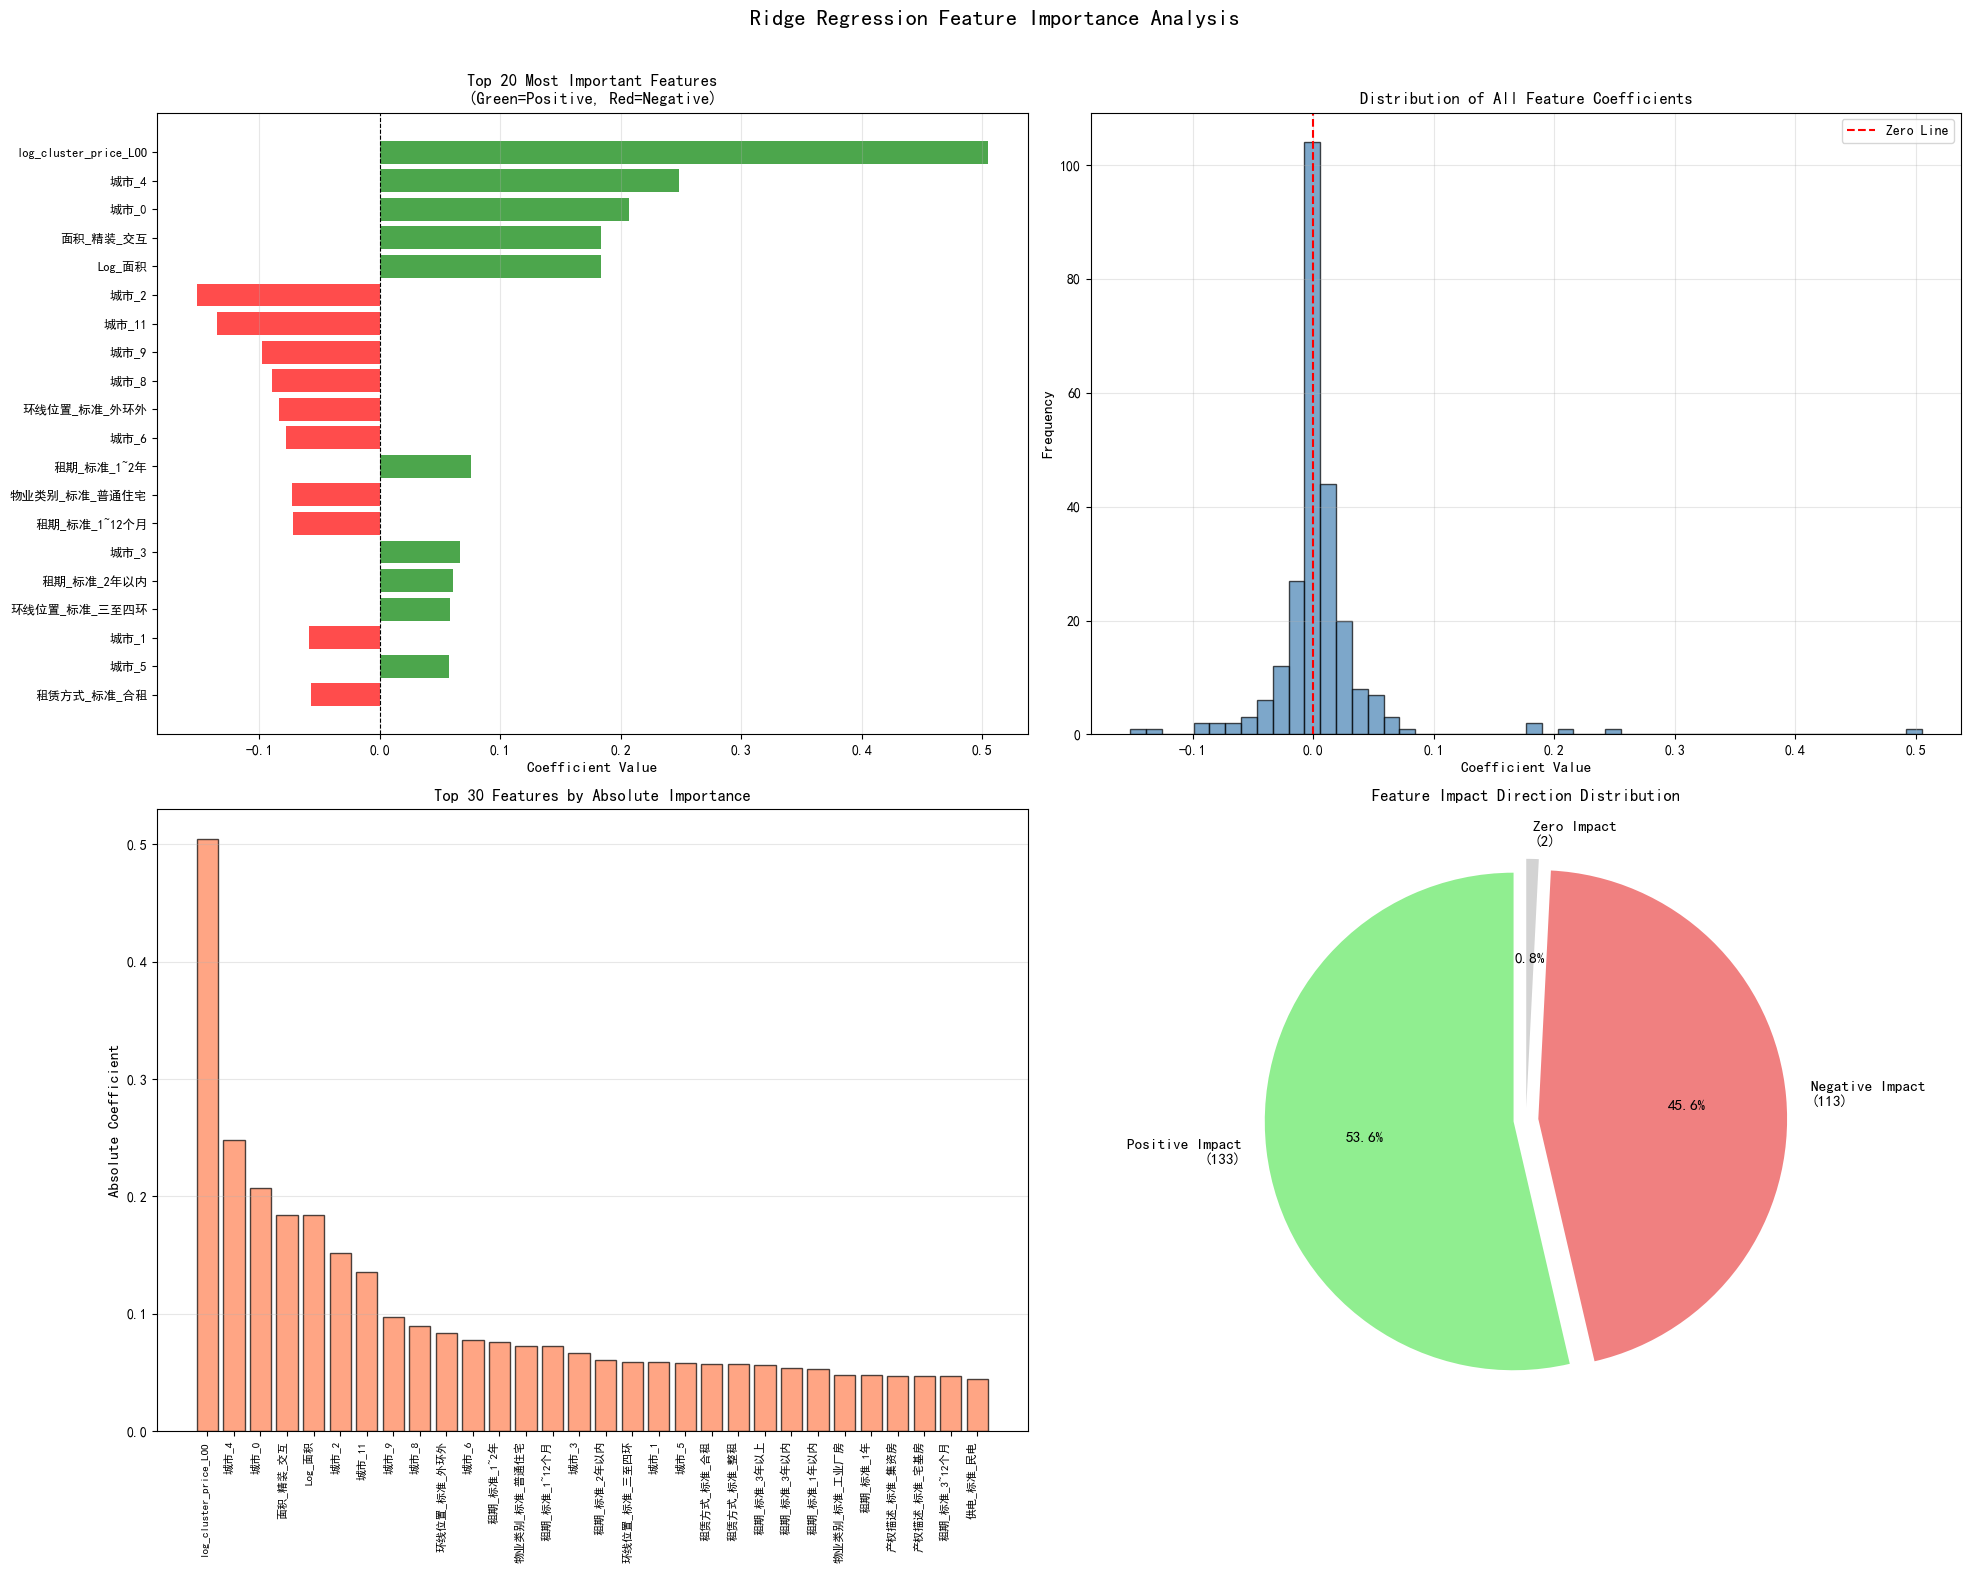


✅ Feature importance analysis complete!


In [36]:
# ==========================================================
# Feature Importance Visualization
# ==========================================================
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']  # 支持中文显示
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# Create figure with multiple subplots
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
fig.suptitle(f'{best_model_type} Regression Feature Importance Analysis', fontsize=16, fontweight='bold')

# 1. Top 20 Features by Absolute Coefficient (Horizontal Bar Chart)
top_20_features = feature_importance_df.head(20)
ax1 = axes[0, 0]
colors = ['green' if x > 0 else 'red' for x in top_20_features['Coefficient']]
ax1.barh(range(len(top_20_features)), top_20_features['Coefficient'], color=colors, alpha=0.7)
ax1.set_yticks(range(len(top_20_features)))
ax1.set_yticklabels(top_20_features['Feature'], fontsize=9)
ax1.set_xlabel('Coefficient Value', fontsize=11, fontweight='bold')
ax1.set_title('Top 20 Most Important Features\n(Green=Positive, Red=Negative)', fontsize=12, fontweight='bold')
ax1.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)

# 2. Distribution of All Coefficients (Histogram)
ax2 = axes[0, 1]
ax2.hist(coefficients, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
ax2.set_xlabel('Coefficient Value', fontsize=11, fontweight='bold')
ax2.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax2.set_title('Distribution of All Feature Coefficients', fontsize=12, fontweight='bold')
ax2.axvline(x=0, color='red', linestyle='--', linewidth=1.5, label='Zero Line')
ax2.legend()
ax2.grid(alpha=0.3)

# 3. Top 30 Features by Absolute Value (Bar Chart)
top_30_abs = feature_importance_df.head(30)
ax3 = axes[1, 0]
ax3.bar(range(len(top_30_abs)), top_30_abs['Abs_Coefficient'], color='coral', alpha=0.7, edgecolor='black')
ax3.set_xticks(range(len(top_30_abs)))
ax3.set_xticklabels(top_30_abs['Feature'], rotation=90, ha='right', fontsize=8)
ax3.set_ylabel('Absolute Coefficient', fontsize=11, fontweight='bold')
ax3.set_title('Top 30 Features by Absolute Importance', fontsize=12, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)

# 4. Positive vs Negative Impact Distribution (Pie Chart)
ax4 = axes[1, 1]
positive_count = (coefficients > 0).sum()
negative_count = (coefficients < 0).sum()
zero_count = (coefficients == 0).sum()

labels = [f'Positive Impact\n({positive_count})', 
          f'Negative Impact\n({negative_count})']
sizes = [positive_count, negative_count]
colors_pie = ['lightgreen', 'lightcoral']
explode = (0.05, 0.05)

if zero_count > 0:
    labels.append(f'Zero Impact\n({zero_count})')
    sizes.append(zero_count)
    colors_pie.append('lightgray')
    explode = (0.05, 0.05, 0.05)

ax4.pie(sizes, labels=labels, colors=colors_pie, autopct='%1.1f%%', 
        startangle=90, explode=explode, textprops={'fontsize': 11, 'fontweight': 'bold'})
ax4.set_title('Feature Impact Direction Distribution', fontsize=12, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.97])
png_filename = f'feature_importance_{best_model_type.lower()}_visualization.png'
plt.savefig(png_filename, dpi=300, bbox_inches='tight')
print(f"\n📊 Visualization saved to: {png_filename}")
plt.show()

print("\n✅ Feature importance analysis complete!")


In [ ]:
# ==========================================================
# 综合性能对比报告：OLS vs Ridge vs Lasso
# ==========================================================
print("\n" + "="*80)
print("📊 模型性能综合对比报告")
print("="*80)

# ------------------------------------------------------------
# 步骤 1: 80/20 数据划分（用于独立测试）
# ------------------------------------------------------------
print("\n🔹 步骤 1/6: 创建 80/20 训练/测试划分...")

# 使用完整的训练数据（包含所有原始特征，但不包含 LOO）
# 注意：我们需要从 df_train 中获取数据，而不是已经预处理过的数据
split_base_features = [col for col in features_to_use if col != 'log_cluster_price_LOO']

X_split_base = df_train[split_base_features].copy()
y_split_log = df_train['Log_Price'].copy()
y_split_original = df_train['Price'].copy()

# 保留 cluster_id 和 Price/m2 用于 LOO 计算
cluster_info_split = df_train[['cluster_id', 'Price/m2']].copy()

# 80/20 划分（所有相关数据一起划分，保持索引一致）
X_train_split, X_test_split, \
y_train_log_split, y_test_log_split, \
y_train_orig_split, y_test_orig_split, \
cluster_train_split, cluster_test_split = train_test_split(
    X_split_base, y_split_log, y_split_original, cluster_info_split,
    test_size=0.2, 
    random_state=42
)

print(f"   ✓ 训练集样本数: {len(X_train_split):,}")
print(f"   ✓ 测试集样本数: {len(X_test_split):,}")

# ------------------------------------------------------------
# 步骤 2: 重新计算 LOO 特征（防止数据泄露）
# ------------------------------------------------------------
print("\n🔹 步骤 2/6: 在 80% 训练集上重新计算 LOO 特征...")

# 为训练集计算 LOO
train_for_loo = pd.DataFrame({
    'cluster_id': cluster_train_split['cluster_id'].values,
    'Price/m2': cluster_train_split['Price/m2'].values
})
train_for_loo = loo_target_encoding(train_for_loo, 'cluster_id', 'Price/m2')
X_train_split['log_cluster_price_LOO'] = np.log(train_for_loo['cluster_id_LOO_Mean'])

# 为测试集映射训练集的聚类均值（不使用测试集自身的价格信息）
cluster_means_split = train_for_loo.groupby('cluster_id')['Price/m2'].mean().to_dict()
train_mean_price_split = train_for_loo['Price/m2'].mean()

X_test_split['cluster_id_LOO_Mean'] = cluster_test_split['cluster_id'].map(cluster_means_split)
X_test_split['cluster_id_LOO_Mean'] = X_test_split['cluster_id_LOO_Mean'].fillna(train_mean_price_split)
X_test_split['log_cluster_price_LOO'] = np.log(X_test_split['cluster_id_LOO_Mean'])

# 移除临时列
X_test_split = X_test_split.drop(columns=['cluster_id_LOO_Mean'], errors='ignore')

print("   ✓ LOO 特征重新计算完成（无数据泄露）")

# ------------------------------------------------------------
# 步骤 3: 预处理数据（标准化）
# ------------------------------------------------------------
print("\n🔹 步骤 3/6: 数据标准化...")

# 使用完整的特征列表（包括新计算的 LOO）
features_for_split = split_base_features + ['log_cluster_price_LOO']

# 创建新的预处理器
scaling_features_split = [col for col in scaling_features_base + ['log_cluster_price_LOO'] 
                          if col in features_for_split]
binary_features_split = [col for col in binary_features if col in features_for_split]

preprocessor_split = ColumnTransformer(
    transformers=[
        ('scaler', StandardScaler(), scaling_features_split),
        ('passthrough', 'passthrough', binary_features_split)
    ],
    remainder='drop'
)

# 填充 NaN
X_train_split_clean = X_train_split[features_for_split].fillna(0)
X_test_split_clean = X_test_split[features_for_split].fillna(0)

X_train_processed_split = preprocessor_split.fit_transform(X_train_split_clean)
X_test_processed_split = preprocessor_split.transform(X_test_split_clean)

print("   ✓ 标准化完成")

# ------------------------------------------------------------
# 步骤 4: 初始化三个模型（使用最优超参数）
# ------------------------------------------------------------
print("\n🔹 步骤 4/6: 初始化模型（使用 CV 选择的最优参数）...")

# 从 CV 结果中找到最优 alpha
# OLS (alpha=0 的 Ridge)
best_ols = {'model_type': 'OLS', 'alpha': None}

# Ridge 最优 alpha
ridge_results = [(alpha, np.nanmean(cv_results['Ridge'][alpha]['MAE'])) 
                 for alpha in alphas_extended]
best_ridge_alpha = min(ridge_results, key=lambda x: x[1])[0]
best_ridge = {'model_type': 'Ridge', 'alpha': best_ridge_alpha}

# Lasso 最优 alpha（排除 alpha=0）
lasso_results = [(alpha, np.nanmean(cv_results['Lasso'][alpha]['MAE'])) 
                 for alpha in alphas_extended if alpha > 0 and len(cv_results['Lasso'][alpha]['MAE']) > 0]
best_lasso_alpha = min(lasso_results, key=lambda x: x[1])[0]
best_lasso = {'model_type': 'Lasso', 'alpha': best_lasso_alpha}

print(f"   ✓ OLS (无正则化)")
print(f"   ✓ Ridge (alpha={best_ridge_alpha})")
print(f"   ✓ Lasso (alpha={best_lasso_alpha})")

# 创建模型实例
ols_model_split = LinearRegression()
ridge_model_split = Ridge(alpha=best_ridge_alpha)
lasso_model_split = OnlineLasso(alpha=best_lasso_alpha, max_iter=10000, warm_start=False)

# ------------------------------------------------------------
# 步骤 5: 训练模型并计算性能（80/20 划分）
# ------------------------------------------------------------
print("\n🔹 步骤 5/6: 训练模型并计算 80/20 划分性能...")

performance_results = []

# 辅助函数：计算指标
def calculate_metrics_split(y_true_log, y_pred_log, y_true_original, metric_type, model_name):
    """计算 MAE 和 RMSE（在原始价格空间）"""
    # 转换预测值回原始空间
    y_pred_log_safe = np.clip(y_pred_log, MIN_LOG_PRICE, MAX_LOG_PRICE)
    y_pred_original = np.exp(y_pred_log_safe)
    
    # 确保没有 NaN 或 Inf
    y_true_safe = y_true_original.fillna(0).replace([np.inf, -np.inf], 0)
    y_pred_safe = pd.Series(y_pred_original).fillna(0).replace([np.inf, -np.inf], 0).values
    
    mae = mean_absolute_error(y_true_safe, y_pred_safe)
    rmse = np.sqrt(mean_squared_error(y_true_safe, y_pred_safe))
    
    return mae, rmse

# --- OLS ---
print("   → 训练 OLS...")
ols_model_split.fit(X_train_processed_split, y_train_log_split)

# In-sample
y_pred_train_ols = ols_model_split.predict(X_train_processed_split)
mae_in, rmse_in = calculate_metrics_split(y_train_log_split, y_pred_train_ols, y_train_orig_split, 'In-sample', 'OLS')
performance_results.append({
    '模型 (Model)': '**OLS**',
    '评估类型 (Metric Type)': 'In-sample (样本内)',
    'MAE (平均绝对误差)': f'{mae_in:,.2f}',
    'RMSE (均方根误差)': f'{rmse_in:,.2f}'
})

# Out-of-sample
y_pred_test_ols = ols_model_split.predict(X_test_processed_split)
mae_out, rmse_out = calculate_metrics_split(y_test_log_split, y_pred_test_ols, y_test_orig_split, 'Out-of-sample', 'OLS')
performance_results.append({
    '模型 (Model)': '**OLS**',
    '评估类型 (Metric Type)': 'Out-of-sample (样本外)',
    'MAE (平均绝对误差)': f'{mae_out:,.2f}',
    'RMSE (均方根误差)': f'{rmse_out:,.2f}'
})

# 6-fold CV
cv_mae_ols = np.nanmean(cv_results['Ridge'][0]['MAE'])  # OLS 对应 alpha=0 的 Ridge
cv_rmse_ols = np.sqrt(np.nanmean([x**2 for x in cv_results['Ridge'][0]['MAE']]))  # 近似 RMSE
performance_results.append({
    '模型 (Model)': '**OLS**',
    '评估类型 (Metric Type)': '6-fold CV (6折交叉验证)',
    'MAE (平均绝对误差)': f'{cv_mae_ols:,.2f}',
    'RMSE (均方根误差)': f'{cv_rmse_ols:,.2f}'
})

# --- Ridge ---
print("   → 训练 Ridge...")
ridge_model_split.fit(X_train_processed_split, y_train_log_split)

# In-sample
y_pred_train_ridge = ridge_model_split.predict(X_train_processed_split)
mae_in, rmse_in = calculate_metrics_split(y_train_log_split, y_pred_train_ridge, y_train_orig_split, 'In-sample', 'Ridge')
performance_results.append({
    '模型 (Model)': '**Ridge**',
    '评估类型 (Metric Type)': 'In-sample (样本内)',
    'MAE (平均绝对误差)': f'{mae_in:,.2f}',
    'RMSE (均方根误差)': f'{rmse_in:,.2f}'
})

# Out-of-sample
y_pred_test_ridge = ridge_model_split.predict(X_test_processed_split)
mae_out, rmse_out = calculate_metrics_split(y_test_log_split, y_pred_test_ridge, y_test_orig_split, 'Out-of-sample', 'Ridge')
performance_results.append({
    '模型 (Model)': '**Ridge**',
    '评估类型 (Metric Type)': 'Out-of-sample (样本外)',
    'MAE (平均绝对误差)': f'{mae_out:,.2f}',
    'RMSE (均方根误差)': f'{rmse_out:,.2f}'
})

# 6-fold CV
cv_mae_ridge = np.nanmean(cv_results['Ridge'][best_ridge_alpha]['MAE'])
cv_rmse_ridge = np.sqrt(np.nanmean([x**2 for x in cv_results['Ridge'][best_ridge_alpha]['MAE']]))
performance_results.append({
    '模型 (Model)': '**Ridge**',
    '评估类型 (Metric Type)': '6-fold CV (6折交叉验证)',
    'MAE (平均绝对误差)': f'{cv_mae_ridge:,.2f}',
    'RMSE (均方根误差)': f'{cv_rmse_ridge:,.2f}'
})

# --- Lasso ---
print("   → 训练 Lasso...")
lasso_model_split.fit(X_train_processed_split, y_train_log_split)

# In-sample
y_pred_train_lasso = lasso_model_split.predict(X_train_processed_split)
mae_in, rmse_in = calculate_metrics_split(y_train_log_split, y_pred_train_lasso, y_train_orig_split, 'In-sample', 'Lasso')
performance_results.append({
    '模型 (Model)': '**Lasso**',
    '评估类型 (Metric Type)': 'In-sample (样本内)',
    'MAE (平均绝对误差)': f'{mae_in:,.2f}',
    'RMSE (均方根误差)': f'{rmse_in:,.2f}'
})

# Out-of-sample
y_pred_test_lasso = lasso_model_split.predict(X_test_processed_split)
mae_out, rmse_out = calculate_metrics_split(y_test_log_split, y_pred_test_lasso, y_test_orig_split, 'Out-of-sample', 'Lasso')
performance_results.append({
    '模型 (Model)': '**Lasso**',
    '评估类型 (Metric Type)': 'Out-of-sample (样本外)',
    'MAE (平均绝对误差)': f'{mae_out:,.2f}',
    'RMSE (均方根误差)': f'{rmse_out:,.2f}'
})

# 6-fold CV
cv_mae_lasso = np.nanmean(cv_results['Lasso'][best_lasso_alpha]['MAE'])
cv_rmse_lasso = np.sqrt(np.nanmean([x**2 for x in cv_results['Lasso'][best_lasso_alpha]['MAE']]))
performance_results.append({
    '模型 (Model)': '**Lasso**',
    '评估类型 (Metric Type)': '6-fold CV (6折交叉验证)',
    'MAE (平均绝对误差)': f'{cv_mae_lasso:,.2f}',
    'RMSE (均方根误差)': f'{cv_rmse_lasso:,.2f}'
})

# ------------------------------------------------------------
# 步骤 6: 生成最终报告表格
# ------------------------------------------------------------
print("\n🔹 步骤 6/6: 生成最终报告...")

results_table = pd.DataFrame(performance_results)

print("\n" + "="*80)
print("🏆 最终性能对比表格")
print("="*80)
print("\n📋 测试集信息:")
print(f"   • 80/20 划分测试集样本数: {len(X_test_split):,}")
print(f"   • 6折交叉验证平均验证集样本数: {len(df_train)//6:,}\n")

print(results_table.to_markdown(index=False))

print("\n" + "="*80)
print("📌 注释说明:")
print("   • In-sample: 在训练集（80%）上的预测性能（可能存在过拟合）")
print("   • Out-of-sample: 在独立测试集（20%）上的预测性能")
print("   • 6-fold CV: 6折交叉验证的平均性能（更可靠的泛化性能估计）")
print("   • 所有指标均在**原始价格空间**（非对数空间）计算")
print("   • LOO 特征已在 80/20 划分后重新计算，确保无数据泄露")
print("="*80)

# 保存结果到CSV
results_table.to_csv('model_performance_comparison_rent.csv', index=False)
print(f"\n💾 性能对比表格已保存至: model_performance_comparison_rent.csv")
print("="*80)



📊 模型性能综合对比报告

🔹 步骤 1/6: 创建 80/20 训练/测试划分...


NameError: name 'features_to_use' is not defined

In [62]:
df_predictions['ID'] = ori_test['ID']

In [63]:
df_predictions.head()

,ID,Price
0,2000000,1.731684e+05
1,2000001,4.510726e+05
2,2000002,3.756047e+05
3,2000003,1.427849e+06
4,2000004,1.053070e+06


In [64]:
df_predictions.to_csv("C:/Users\lenovo\Desktop/rent_1029", index = False)